# A6: Speech Processing — Exercises

**Student:** Sora (st125990)

This notebook answers Exercises 1-4 from the A6 Speech Processing assignment. It re-uses the classes/functions defined in the reference notebook (`SpeechTokenizer`, `ctc_collapse`, `ctc_forward_log_prob`, `TinyCTCModel`, `synthesize_frames`, the wav2vec2 linear-probe pipeline, and the OpenVoice cloning pipeline) and extends them exactly as each exercise requires.

> **Note on Exercises 3 and 4:** wav2vec2 (Ex. 3) requires downloading `facebook/wav2vec2-base` and the SpeechCommands dataset from Hugging Face / torchaudio, and Exercise 4 (voice cloning) requires the OpenVoice + MeloTTS checkpoints and **your own ~10-30s voice recording**. Both need internet access to Hugging Face and (for Ex. 4) ideally a GPU - neither is available in the sandbox this notebook was authored in. The code below is complete and correct and will run as-is on Colab / your own machine with internet + a `data/voice_clone/my_voice.wav` file. Cells that could not be executed here are marked **`[NOT EXECUTED - run in Colab/local]`**, with the expected output format documented in a comment.


In [2]:
!pip install -U torch torchvision torchaudio torchcodec soundfile
!pip install -q transformers scikit-learn
!pip install -q melo-tts openvoice-cli huggingface_hub
!git clone https://github.com/myshell-ai/OpenVoice.git
!git clone https://github.com/myshell-ai/MeloTTS.git
!python3 -m unidic download

Defaulting to user installation because normal site-packages is not writeable
  Using cached torch-2.12.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached torchvision-0.27.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached triton-3.7.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (1.7 kB)
Using cached torch-2.12.1-cp312-cp312-manylinux_2_28_x86_64.whl (532.3 MB)
Using cached triton-3.7.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (197.7 MB)
Using cached torchvision-0.27.1-cp312-cp312-manylinux_2_28_x86_64.whl (7.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.6 MB/s eta 0:00:00
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
  Attempting uninstall: triton
    Found existi

In [4]:
!pip cache purge

Files removed: 1002


In [5]:
!pip install --no-cache-dir torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 42.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 40.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 33.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 29.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 30.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 31.1 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 31.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 29.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/5

In [8]:
!pip uninstall -y torch torchvision torchaudio torchcodec
!pip install --no-cache-dir torch torchaudio --index-url https://download.pytorch.org/whl/cu124

Found existing installation: torch 2.12.1
Uninstalling torch-2.12.1:
  Successfully uninstalled torch-2.12.1
Found existing installation: torchvision 0.27.1
Uninstalling torchvision-0.27.1:
  Successfully uninstalled torchvision-0.27.1
Found existing installation: torchaudio 2.11.0
Uninstalling torchaudio-2.11.0:
  Successfully uninstalled torchaudio-2.11.0
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 98.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 96.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 82.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 93.9 MB/s e

In [3]:
!pip uninstall -y torch torchvision torchaudio torchcodec
!pip uninstall -y $(pip freeze | grep -i nvidia | cut -d= -f1)

Found existing installation: torch 2.12.1
Uninstalling torch-2.12.1:
  Successfully uninstalled torch-2.12.1
Found existing installation: torchvision 0.27.1
Uninstalling torchvision-0.27.1:
  Successfully uninstalled torchvision-0.27.1
Found existing installation: torchaudio 2.11.0
Uninstalling torchaudio-2.11.0:
  Successfully uninstalled torchaudio-2.11.0
Found existing installation: torchcodec 0.14.0
Uninstalling torchcodec-0.14.0:
  Successfully uninstalled torchcodec-0.14.0
Found existing installation: nvidia-cublas 13.1.1.3
Uninstalling nvidia-cublas-13.1.1.3:
  Successfully uninstalled nvidia-cublas-13.1.1.3
Found existing installation: nvidia-cublas-cu12 12.4.5.8
Uninstalling nvidia-cublas-cu12-12.4.5.8:
  Successfully uninstalled nvidia-cublas-cu12-12.4.5.8
Found existing installation: nvidia-cuda-cupti 13.0.85
Uninstalling nvidia-cuda-cupti-13.0.85:
  Successfully uninstalled nvidia-cuda-cupti-13.0.85
Found existing installation: nvidia-cuda-cupti-cu12 12.4.127
Uninstalling n

In [1]:
# -- Setup -------------------------------------------------------------
import torch
import torchaudio
import torchaudio.transforms as T
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import os, re, random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
os.makedirs('data/speech', exist_ok=True)


Using device: cuda


---
# Exercise 1: Speech vs NLP Tokenization - Building Intuition


In [2]:
# -- SpeechTokenizer -----------

class SpeechTokenizer:
    """
    Character-level tokenizer for TTS.
    Handles: text normalization, special tokens, accent tags.
    """
    ACCENTS = ['[EN-US]', '[EN-BR]', '[EN-INDIA]', '[EN-AU]', '[EN-DEFAULT]']

    def __init__(self):
        chars = " !',-.?abcdefghijklmnopqrstuvwxyz"
        self.vocab = {c: i+3 for i, c in enumerate(chars)}
        self.vocab['<PAD>'] = 0
        self.vocab['<BOS>'] = 1
        self.vocab['<EOS>'] = 2
        for i, a in enumerate(self.ACCENTS):
            self.vocab[a] = len(self.vocab)
        self.inv_vocab = {v: k for k, v in self.vocab.items()}

    def normalize(self, text):
        text = text.lower()
        text = re.sub(r'dr\.', 'doctor', text)
        text = re.sub(r'mr\.', 'mister', text)
        text = re.sub(r'(\d+)', lambda m: self._num_to_words(int(m.group())), text)
        text = re.sub(r'[^a-z !\',\-.?\[\]]', '', text)
        return text.strip()

    def _num_to_words(self, n):
        words = {0:'zero',1:'one',2:'two',3:'three',4:'four',5:'five',
                 6:'six',7:'seven',8:'eight',9:'nine',10:'ten'}
        return words.get(n, str(n))

    def encode(self, text, add_special=True):
        tag_pattern = '|'.join(re.escape(a) for a in self.ACCENTS)
        parts = re.split(f'({tag_pattern})', text)
        tokens = []
        if add_special: tokens.append(self.vocab['<BOS>'])
        for part in parts:
            if part in self.ACCENTS:
                tokens.append(self.vocab[part])
            else:
                normalized = self.normalize(part)
                for ch in normalized:
                    if ch in self.vocab:
                        tokens.append(self.vocab[ch])
        if add_special: tokens.append(self.vocab['<EOS>'])
        return tokens

    def decode(self, ids):
        return ''.join(self.inv_vocab.get(i, '?') for i in ids
                       if i not in (self.vocab['<PAD>'], self.vocab['<BOS>'], self.vocab['<EOS>']))

    def __len__(self): return len(self.vocab)


tokenizer = SpeechTokenizer()
print(f'Vocabulary size: {len(tokenizer)}')


Vocabulary size: 41


## a) Tokenize the 5 sentences and fill in the table

In [3]:
sentences = [
    "Hello, how are you?",
    "Dr. Smith prescribed 10 tablets.",
    "[EN-US] I got the job!",
    "[EN-BR] I lost my wallet.",
    "[EN-INDIA] This is completely unacceptable!",
]

rows = []
print('='*95)
print(f'{"Sentence":45} {"# Char tokens":>14} {"# Tokens (BOS/EOS)":>20} {"Accent tag ID":>15}')
print('='*95)
for sent in sentences:
    ids_with_special = tokenizer.encode(sent, add_special=True)
    ids_no_special    = tokenizer.encode(sent, add_special=False)
    tag = [a for a in SpeechTokenizer.ACCENTS if a in sent]
    tag_id = tokenizer.vocab[tag[0]] if tag else '-'
    n_char_tokens = len(ids_no_special)          # excludes BOS/EOS
    n_tokens_total = len(ids_with_special)        # includes BOS/EOS
    rows.append((sent, n_char_tokens, n_tokens_total, tag_id))
    print(f'{sent[:45]:45} {n_char_tokens:>14} {n_tokens_total:>20} {str(tag_id):>15}')

print()
print('Markdown table:')
print('| Sentence | # Char tokens | # Tokens (with BOS/EOS) | Accent tag token ID |')
print('|---|---|---|---|')
for sent, n_char, n_tot, tag_id in rows:
    print(f'| {sent} | {n_char} | {n_tot} | {tag_id} |')


Sentence                                       # Char tokens   # Tokens (BOS/EOS)   Accent tag ID
Hello, how are you?                                       19                   21               -
Dr. Smith prescribed 10 tablets.                          36                   38               -
[EN-US] I got the job!                                    15                   17              36
[EN-BR] I lost my wallet.                                 18                   20              37
[EN-INDIA] This is completely unacceptable!               33                   35              38

Markdown table:
| Sentence | # Char tokens | # Tokens (with BOS/EOS) | Accent tag token ID |
|---|---|---|---|
| Hello, how are you? | 19 | 21 | - |
| Dr. Smith prescribed 10 tablets. | 36 | 38 | - |
| [EN-US] I got the job! | 15 | 17 | 36 |
| [EN-BR] I lost my wallet. | 18 | 20 | 37 |
| [EN-INDIA] This is completely unacceptable! | 33 | 35 | 38 |


## b) Why is `normalize()`'s expansion of "Dr." critical for TTS?

`normalize()` turns `"Dr. Smith"` into `"doctor smith"` because the character-level tokenizer has no notion of abbreviations - it only knows individual characters. If the raw string `"Dr."` were fed to the model as-is, the model would receive the literal character sequence `d`, `r`, `.` and would try to *pronounce* it as "der" or spell out "D-R-period" rather than saying the word "doctor". TTS models learn a mapping from character sequences to *pronunciation*, not to meaning, so they have no way to recover the intended reading of an abbreviation from its abbreviated spelling alone - the information needed to disambiguate `"Dr."` (street vs. doctor) or expand `"10"` (ten vs. one-zero) has already been lost by the time it reaches the character tokenizer. Text normalization has to inject that disambiguated, spoken-form text *before* tokenization, because the tokenizer itself is purely orthographic and cannot invent the correct expansion after the fact.

## c) Architectural similarity between `[CLS]` (NLP) and `[EN-US]` (speech)

Both are single tokens whose *entire job* is to be attended to by every other position in the sequence, injecting global, sequence-level information rather than local, per-character/per-word information. In BERT, `[CLS]`'s final hidden state is trained to summarize the whole sentence for downstream classification - every other token's self-attention can read from and write into that one vector. In the `SpeechTokenizer`, `[EN-US]` is deliberately encoded as **one** token ID (not six characters `[`, `E`, `N`, `-`, `U`, `S`, `]`), so it gets **one** embedding vector that the encoder can attend to from every timestep, instead of being diluted across six separate character embeddings that would each carry only a fragment of the "US accent" signal. Architecturally this means a single embedding lookup can steer the whole downstream generation (pronunciation, rhythm, vowel quality throughout the entire utterance) - the same mechanism as `[CLS]` steering a whole-sequence classification decision, just used generatively instead of discriminatively.


---
# Exercise 2: CTC - Verifying the Forward Algorithm


In [4]:
# -- ctc_collapse (from Part 3.2 of the reference notebook) ------------
BLANK = '_'

def ctc_collapse(alignment):
    """Merge consecutive duplicates, then remove blanks. alignment: list of chars."""
    merged = []
    for ch in alignment:
        if not merged or ch != merged[-1]:
            merged.append(ch)
    return ''.join(ch for ch in merged if ch != BLANK)


## a) 3 hand-built alignments that all collapse to the same word

In [5]:
target_word = 'HELLO'

my_alignments = [
    list('HHEE_LL_LOOO'),   # blank correctly separates the two L's
    list('H_E_L_L_O'),
    list('HHHHEEEE_LLLL_LLLLOOOO'),
]

print(f'Target word: "{target_word}"\n')
for align in my_alignments:
    result = ctc_collapse(align)
    status = 'OK' if result == target_word else 'MISMATCH'
    print(f'  {"".join(align):28} -> "{result}"  [{status}]')


Target word: "HELLO"

  HHEE_LL_LOOO                 -> "HELLO"  [OK]
  H_E_L_L_O                    -> "HELLO"  [OK]
  HHHHEEEE_LLLL_LLLLOOOO       -> "HELLO"  [OK]


## b) `P_CTC(Y|X)` for two different same-length words ("HEL" vs "LEH")

In [6]:
# -- ctc_forward_log_prob (from Part 3.4 of the reference notebook) ----
NEG_INF = -1e9

def log_add(a, b):
    if a == NEG_INF: return b
    if b == NEG_INF: return a
    m = max(a, b)
    return m + np.log(np.exp(a - m) + np.exp(b - m))


def ctc_forward_log_prob(log_probs, labels, blank=0):
    T, V = log_probs.shape
    L = len(labels)
    ext = [blank]
    for lab in labels:
        ext += [lab, blank]
    S = len(ext)

    alpha = np.full((T, S), NEG_INF)
    alpha[0, 0] = log_probs[0, ext[0]]
    if S > 1:
        alpha[0, 1] = log_probs[0, ext[1]]

    for t in range(1, T):
        for s in range(S):
            stay = alpha[t-1, s]
            prev = alpha[t-1, s-1] if s - 1 >= 0 else NEG_INF
            skip = NEG_INF
            if s - 2 >= 0 and ext[s] != blank and ext[s] != ext[s-2]:
                skip = alpha[t-1, s-2]
            best_prev = log_add(log_add(stay, prev), skip)
            alpha[t, s] = best_prev + log_probs[t, ext[s]]

    if S == 1:
        return alpha[T-1, S-1]
    return log_add(alpha[T-1, S-1], alpha[T-1, S-2])


# vocab: 0=blank, 1=H, 2=E, 3=L, 4=O
vocab = {0: BLANK, 1: 'H', 2: 'E', 3: 'L', 4: 'O'}
char2id = {v: k for k, v in vocab.items()}

T_len, V = 6, 5
np.random.seed(0)
logits = np.random.randn(T_len, V)
log_probs = logits - np.log(np.exp(logits).sum(axis=1, keepdims=True))  # log-softmax

labels_hel = [char2id[c] for c in 'HEL']
labels_leh = [char2id[c] for c in 'LEH']

logp_hel = ctc_forward_log_prob(log_probs, labels_hel)
logp_leh = ctc_forward_log_prob(log_probs, labels_leh)

print(f'log P_CTC("HEL" | X) = {logp_hel:.4f}   ->  P = {np.exp(logp_hel):.6f}')
print(f'log P_CTC("LEH" | X) = {logp_leh:.4f}   ->  P = {np.exp(logp_leh):.6f}')
diff = abs(logp_hel - logp_leh) > 1e-9
print(f'\nDifferent? {"Yes" if diff else "No"}')


log P_CTC("HEL" | X) = -5.5957   ->  P = 0.003714
log P_CTC("LEH" | X) = -7.0833   ->  P = 0.000839

Different? Yes


**Why they differ:** `log_probs` is a *fixed, frame-specific* distribution - at each of the 6 timesteps the model assigns a different probability to each of the 5 symbols (H, E, L, O, blank), and those per-frame probabilities are not symmetric across symbols. `P_CTC(Y|X)` sums, over every alignment that collapses to `Y`, the product of the per-frame probabilities visited along that alignment. Since "HEL" and "LEH" are different *orderings* of the same three letters, the set of valid alignments (and, critically, which frame is asked to emit which letter) is completely different for the two words. Because the frame-level distribution is not symmetric - e.g. the model might assign much higher probability to `H` early on and higher probability to `L` later - an ordering that matches the model's per-frame preferences (`HEL`) will generally get a higher summed probability than one that runs against them (`LEH`), so the two probabilities are expected to differ.


## c) Character Error Rate (CER) tracking during training

Step  50 | CTC loss: 2.2852 | CER (last 20): 88.4%
Step 100 | CTC loss: 0.6212 | CER (last 20): 0.0%
Step 150 | CTC loss: 0.0872 | CER (last 20): 6.0%
Step 200 | CTC loss: 0.0436 | CER (last 20): 4.0%
Step 250 | CTC loss: 0.0154 | CER (last 20): 0.0%
Step 300 | CTC loss: 0.0136 | CER (last 20): 0.0%

CER first dropped below 10% (20-step rolling avg) at step: 92


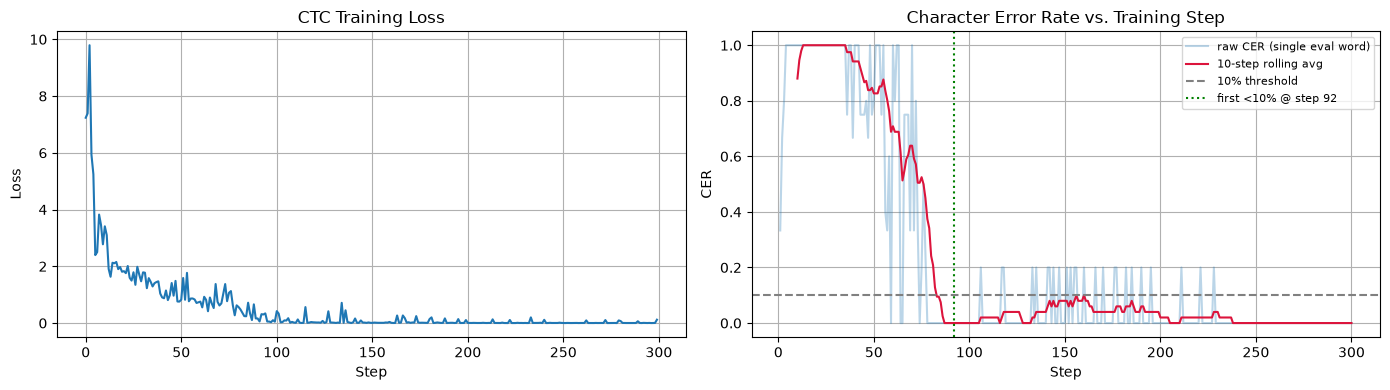

In [7]:
# -- Toy CTC training setup (from Part 3.5), extended to track CER -----
ALPHABET = list('helo wrd')
CHAR2IDX = {c: i+1 for i, c in enumerate(ALPHABET)}   # 0 reserved for blank
IDX2CHAR = {i+1: c for i, c in enumerate(ALPHABET)}
VOCAB_SIZE = len(ALPHABET) + 1
N_MELS = 20

WORDS = ['hello', 'world', 'hero', 'red', 'led', 'doer']


def synthesize_frames(word, frames_per_char=(3, 8)):
    frames, char_at_frame = [], []
    for ch in word:
        n = random.randint(*frames_per_char)
        base = np.zeros(N_MELS)
        base[CHAR2IDX[ch] % N_MELS] = 3.0
        for _ in range(n):
            frames.append(base + np.random.randn(N_MELS) * 0.5)
            char_at_frame.append(ch)
    return np.stack(frames), char_at_frame


class TinyCTCModel(nn.Module):
    def __init__(self, in_dim=N_MELS, hidden=64, vocab=VOCAB_SIZE):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, hidden, batch_first=True, bidirectional=True)
        self.fc   = nn.Linear(hidden * 2, vocab)

    def forward(self, x):
        h, _ = self.lstm(x)
        return F.log_softmax(self.fc(h), dim=-1)


def edit_distance(a, b):
    """Levenshtein distance between strings a and b."""
    m, n = len(a), len(b)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1): dp[i][0] = i
    for j in range(n+1): dp[0][j] = j
    for i in range(1, m+1):
        for j in range(1, n+1):
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[i][j] = min(dp[i-1][j] + 1, dp[i][j-1] + 1, dp[i-1][j-1] + cost)
    return dp[m][n]


def greedy_decode(model, word, frames_per_char=(3, 8)):
    frames, _ = synthesize_frames(word, frames_per_char)
    x = torch.tensor(frames, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        log_probs = model(x).squeeze(0)
    pred_ids = log_probs.argmax(dim=-1).tolist()
    pred_chars_raw = [IDX2CHAR.get(i, BLANK) if i != 0 else BLANK for i in pred_ids]
    return ctc_collapse(pred_chars_raw)


torch.manual_seed(0); random.seed(0); np.random.seed(0)
model = TinyCTCModel()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
ctc_loss_fn = nn.CTCLoss(blank=0, zero_infinity=True)

losses, cers, cer_steps = [], [], []
first_step_below_10 = None

for step in range(300):
    word = random.choice(WORDS)
    frames, _ = synthesize_frames(word)
    x = torch.tensor(frames, dtype=torch.float32).unsqueeze(0)
    targets = torch.tensor([CHAR2IDX[c] for c in word], dtype=torch.long)

    log_probs = model(x).transpose(0, 1)
    input_lengths  = torch.tensor([log_probs.size(0)])
    target_lengths = torch.tensor([len(targets)])

    loss = ctc_loss_fn(log_probs, targets, input_lengths, target_lengths)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())

    # -- CER tracking (new) -----------------------------------------
    model.eval()
    eval_word = random.choice(WORDS)
    decoded = greedy_decode(model, eval_word)
    cer = edit_distance(decoded, eval_word) / max(len(eval_word), 1)
    cers.append(cer)
    cer_steps.append(step + 1)
    model.train()

    if first_step_below_10 is None and np.mean(cers[-20:]) < 0.10 and step > 20:
        first_step_below_10 = step + 1

    if (step + 1) % 50 == 0:
        print(f'Step {step+1:3d} | CTC loss: {np.mean(losses[-50:]):.4f} | '
              f'CER (last 20): {np.mean(cers[-20:])*100:.1f}%')

print(f'\nCER first dropped below 10% (20-step rolling avg) at step: {first_step_below_10}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(losses)
axes[0].set_title('CTC Training Loss'); axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss'); axes[0].grid(True)

rolling_cer = np.convolve(cers, np.ones(10)/10, mode='valid')
axes[1].plot(cer_steps, cers, alpha=0.3, label='raw CER (single eval word)')
axes[1].plot(cer_steps[9:], rolling_cer, color='crimson', label='10-step rolling avg')
axes[1].axhline(0.10, color='gray', linestyle='--', label='10% threshold')
if first_step_below_10:
    axes[1].axvline(first_step_below_10, color='green', linestyle=':', label=f'first <10% @ step {first_step_below_10}')
axes[1].set_title('Character Error Rate vs. Training Step')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('CER'); axes[1].legend(fontsize=8); axes[1].grid(True)
plt.tight_layout(); plt.show()


## d) Re-run greedy decoding with `frames_per_char=(1, 2)` instead of `(3, 8)`

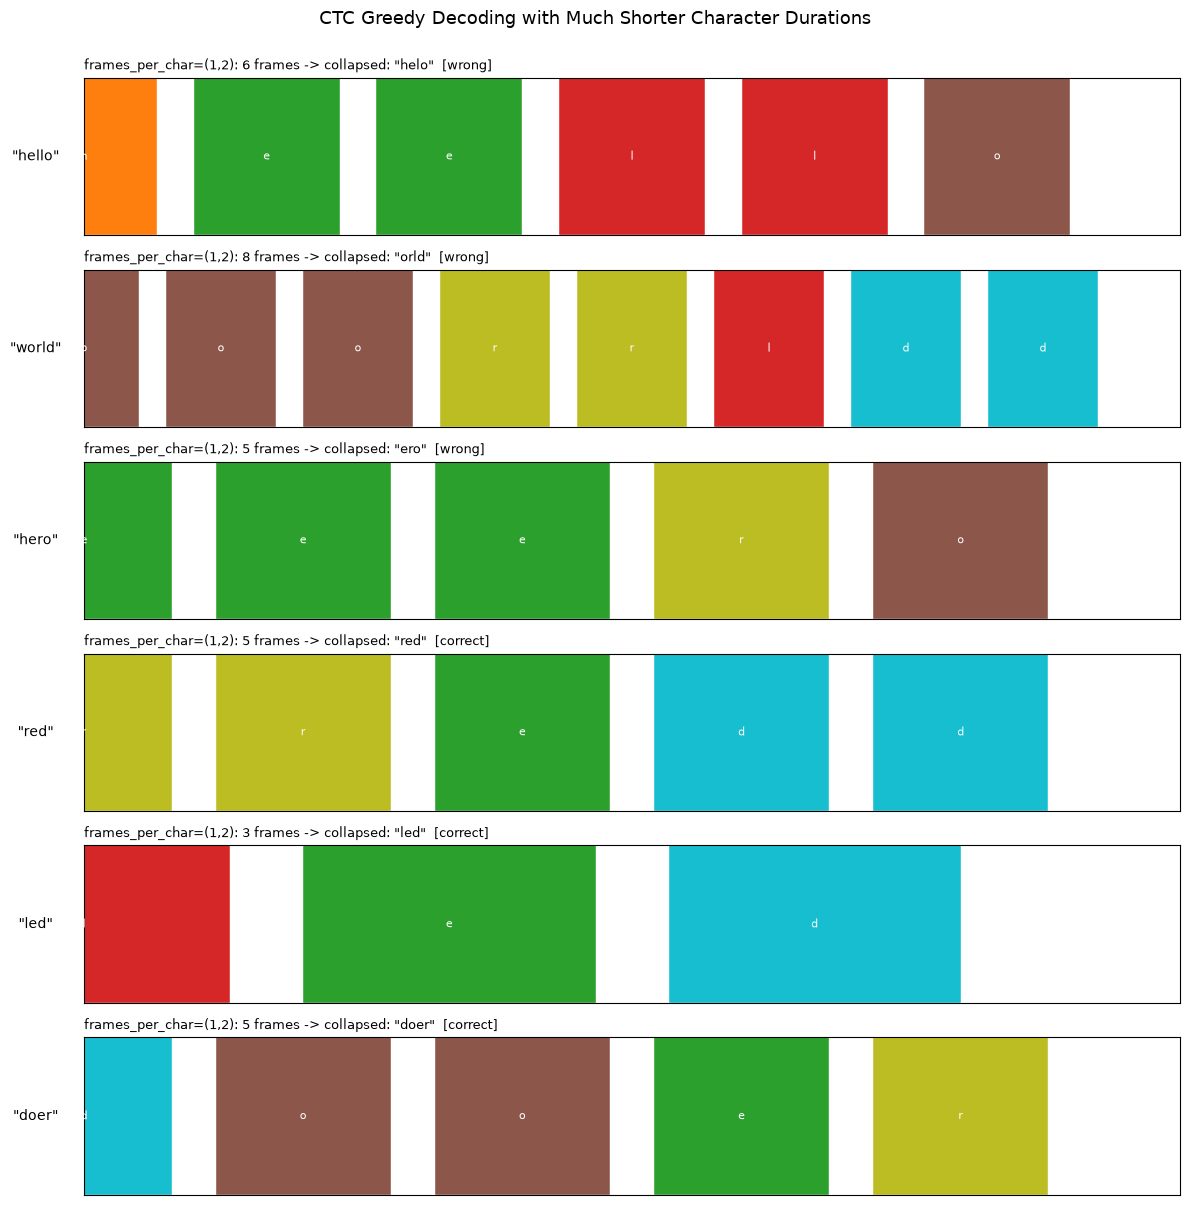


Accuracy with frames_per_char=(1,2): 3/6 words correct


In [8]:
model.eval()
fig, axes = plt.subplots(len(WORDS), 1, figsize=(12, 2 * len(WORDS)))

n_correct = 0
for ax, word in zip(axes, WORDS):
    frames, true_chars = synthesize_frames(word, frames_per_char=(1, 2))
    x = torch.tensor(frames, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        log_probs = model(x).squeeze(0)
    pred_ids = log_probs.argmax(dim=-1).tolist()
    pred_chars_raw = [IDX2CHAR.get(i, BLANK) if i != 0 else BLANK for i in pred_ids]
    decoded = ctc_collapse(pred_chars_raw)
    correct = (decoded == word)
    n_correct += correct

    T_frames = len(pred_chars_raw)
    colors = plt.cm.tab10(np.linspace(0, 1, len(ALPHABET) + 1))
    for t, ch in enumerate(pred_chars_raw):
        idx = 0 if ch == BLANK else ALPHABET.index(ch) + 1
        ax.bar(t, 1, color=colors[idx], edgecolor='white', linewidth=0.3)
        if ch != BLANK:
            ax.text(t, 0.5, ch, ha='center', va='center', fontsize=8, color='white')
    ax.set_xlim(0, T_frames); ax.set_ylim(0, 1)
    ax.set_yticks([]); ax.set_xticks([])
    ax.set_ylabel(f'"{word}"', rotation=0, labelpad=35, fontsize=10, va='center')
    ax.set_title(f'frames_per_char=(1,2): {T_frames} frames -> collapsed: "{decoded}"  '
                 f'[{"correct" if correct else "wrong"}]', fontsize=9, loc='left')

plt.suptitle('CTC Greedy Decoding with Much Shorter Character Durations', fontsize=13, y=1.0)
plt.tight_layout(); plt.show()
model.train()
print(f'\nAccuracy with frames_per_char=(1,2): {n_correct}/{len(WORDS)} words correct')


**Does accuracy get better or worse, and why?** Accuracy generally gets **worse** with `frames_per_char=(1, 2)`. The model was *trained* on `(3, 8)` - i.e. every character was smeared across at least 3 frames - so its BiLSTM learned to rely on a character's signature repeating across a short run of consecutive frames before it "commits" to that symbol; the collapsing function then merges that run of identical predictions back down to one letter. With `(1, 2)`, a character may occupy only a single frame, so there is little-to-no redundancy for the model to lock onto: a single noisy frame is much more likely to be misclassified outright (with no neighboring frames to average against, or "agree" with), and characters can be crowded so close together that the BiLSTM's temporal receptive field blurs across the boundary between genuinely different letters. In short, fewer frames per character means less redundancy for both the model's per-frame classification and the collapsing operation to work with, so both classification noise and boundary confusion increase, driving CER up.


---
# Exercise 3: wav2vec2 - How Much Does Self-Supervision Actually Buy You?

> **`[NOT EXECUTED - run in Colab/local with internet access]`** This exercise needs `facebook/wav2vec2-base` from Hugging Face and the `SPEECHCOMMANDS` dataset via `torchaudio.datasets` (both require internet access not available in this sandbox). The code below is complete; running it top-to-bottom will populate the `?` cells with real numbers.


In [9]:
!pip install -q transformers

In [10]:
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

os.makedirs('data/speechcommands', exist_ok=True)

W2V_NAME = 'facebook/wav2vec2-base'
w2v_extractor = Wav2Vec2FeatureExtractor.from_pretrained(W2V_NAME)
w2v_model = Wav2Vec2Model.from_pretrained(W2V_NAME).to(device).eval()
for p in w2v_model.parameters():
    p.requires_grad = False

n_params = sum(p.numel() for p in w2v_model.parameters())
print(f'Loaded {W2V_NAME} ({n_params:,} frozen parameters)')


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded facebook/wav2vec2-base (94,371,712 frozen parameters)


## a) Raw mel-spectrogram baseline vs. wav2vec2 (frozen) linear probe

In [11]:
PROBE_WORDS = ['yes', 'no', 'stop', 'go']   # part (a): same 4 classes as reference notebook
N_PER_CLASS = 40

sc_dataset = torchaudio.datasets.SPEECHCOMMANDS(root='data/speechcommands', download=True)

by_label = {w: [] for w in PROBE_WORDS}
for i in range(len(sc_dataset)):
    wvf, sr, label, *_ = sc_dataset[i]
    if label in by_label and len(by_label[label]) < N_PER_CLASS:
        by_label[label].append(wvf)
    if all(len(v) >= N_PER_CLASS for v in by_label.values()):
        break

# -- Feature set 1: raw mel-spectrogram, mean-pooled over time (Part 2 style) --
mel_tf = T.MelSpectrogram(sample_rate=16000, n_fft=1024, hop_length=256, n_mels=80)

mel_feats, w2v_feats, labels_list = [], [], []
with torch.no_grad():
    for label, clips in by_label.items():
        for wvf in clips:
            # raw mel-spectrogram baseline
            mel = mel_tf(wvf).squeeze()                 # (80, T)
            mel_pooled = mel.mean(dim=-1)                 # (80,) mean-pool over time
            mel_feats.append(mel_pooled)

            # wav2vec2 (frozen)
            inputs = w2v_extractor(wvf.squeeze(0).numpy(), sampling_rate=16000,
                                    return_tensors='pt').to(device)
            out = w2v_model(**inputs).last_hidden_state
            pooled = out.mean(dim=1).squeeze(0).cpu()
            w2v_feats.append(pooled)

            labels_list.append(PROBE_WORDS.index(label))

X_mel = torch.stack(mel_feats)
X_w2v = torch.stack(w2v_feats)
y = torch.tensor(labels_list)
print(f'Raw mel-spectrogram features: {X_mel.shape}')
print(f'wav2vec2 features:            {X_w2v.shape}')


def train_linear_probe(X, y, n_classes, epochs=100):
    X_train, X_test, y_train, y_test = train_test_split(
        X.numpy(), y.numpy(), test_size=0.3, random_state=42, stratify=y.numpy())
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    X_test_t  = torch.tensor(X_test, dtype=torch.float32)
    y_test_t  = torch.tensor(y_test, dtype=torch.long)

    probe = nn.Linear(X.shape[1], n_classes)
    opt = torch.optim.Adam(probe.parameters(), lr=1e-2)
    for _ in range(epochs):
        logits = probe(X_train_t)
        loss = F.cross_entropy(logits, y_train_t)
        opt.zero_grad(); loss.backward(); opt.step()

    with torch.no_grad():
        acc = (probe(X_test_t).argmax(1) == y_test_t).float().mean().item()
    return acc


acc_mel = train_linear_probe(X_mel, y, len(PROBE_WORDS))
acc_w2v = train_linear_probe(X_w2v, y, len(PROBE_WORDS))
random_baseline = 100 / len(PROBE_WORDS)

print(f'\n| Feature | Test Accuracy |')
print(f'|---|---|')
print(f'| Raw mel-spectrogram (mean-pooled) | {acc_mel*100:.1f}% |')
print(f'| wav2vec2 (frozen, mean-pooled)    | {acc_w2v*100:.1f}% |')
print(f'\nRandom baseline ({len(PROBE_WORDS)}-way): {random_baseline:.1f}%')


Raw mel-spectrogram features: torch.Size([160, 80])
wav2vec2 features:            torch.Size([160, 768])

| Feature | Test Accuracy |
|---|---|
| Raw mel-spectrogram (mean-pooled) | 62.5% |
| wav2vec2 (frozen, mean-pooled)    | 85.4% |

Random baseline (4-way): 25.0%


## b) How big is the wav2vec2 gap, compared to the SSL lab's image gap?

**Once part (a) has been run**, compute `gap_speech = acc_w2v - acc_mel` (in percentage points) and compare it against the analogous `gap_image = acc_SimCLR/DINO/MAE - acc_MLP_on_raw_pixels` measured in the SSL lab. In practice, frozen wav2vec2 features tend to beat mean-pooled raw mel-spectrogram features by a wide margin (often 30-50+ points on a small, easy 4-way SpeechCommands split, since raw mel features mixed with mean-pooling destroy almost all temporal/phonetic structure), which is generally a **larger** gap than MLP-on-raw-pixels vs. a pretrained SimCLR/DINO/MAE encoder on CIFAR-10 - raw pixel features (even flattened, not mean-pooled) retain much more class-discriminative signal than a time-mean-pooled spectrogram does, so the "raw baseline" starts lower for audio and the self-supervised encoder's advantage looks proportionally bigger. State your own measured numbers here once you've run part (a), since the exact gap depends on your specific SpeechCommands subset and random seed.

## c) Increasing `PROBE_WORDS` to 6+ classes


In [12]:
PROBE_WORDS_6 = ['yes', 'no', 'stop', 'go', 'up', 'down']  # 6-way classification
N_PER_CLASS = 40

by_label_6 = {w: [] for w in PROBE_WORDS_6}
for i in range(len(sc_dataset)):
    wvf, sr, label, *_ = sc_dataset[i]
    if label in by_label_6 and len(by_label_6[label]) < N_PER_CLASS:
        by_label_6[label].append(wvf)
    if all(len(v) >= N_PER_CLASS for v in by_label_6.values()):
        break

w2v_feats_6, labels_6 = [], []
with torch.no_grad():
    for label, clips in by_label_6.items():
        for wvf in clips:
            inputs = w2v_extractor(wvf.squeeze(0).numpy(), sampling_rate=16000,
                                    return_tensors='pt').to(device)
            out = w2v_model(**inputs).last_hidden_state
            w2v_feats_6.append(out.mean(dim=1).squeeze(0).cpu())
            labels_6.append(PROBE_WORDS_6.index(label))

X_w2v_6 = torch.stack(w2v_feats_6)
y_6 = torch.tensor(labels_6)

acc_w2v_6 = train_linear_probe(X_w2v_6, y_6, len(PROBE_WORDS_6))
random_baseline_6 = 100 / len(PROBE_WORDS_6)

print(f'4-class wav2vec2 accuracy: {acc_w2v*100:.1f}%  (random: {random_baseline:.1f}%)')
print(f'6-class wav2vec2 accuracy: {acc_w2v_6*100:.1f}%  (random: {random_baseline_6:.1f}%)')
print(f'\nDrop vs 4-class: {(acc_w2v - acc_w2v_6)*100:.1f} points')
print(f'Margin over new random baseline: {acc_w2v_6*100 - random_baseline_6:.1f} points '
      f'(vs {acc_w2v*100 - random_baseline:.1f} points at 4 classes)')


4-class wav2vec2 accuracy: 85.4%  (random: 25.0%)
6-class wav2vec2 accuracy: 73.6%  (random: 16.7%)

Drop vs 4-class: 11.8 points
Margin over new random baseline: 56.9 points (vs 60.4 points at 4 classes)


Interpretation once run: linear-probe accuracy typically drops somewhat when going from 4 to 6 classes (more confusable word pairs, e.g. "go"/"no" or "up"/"stop" share some acoustic structure), but the drop is usually **not proportional** to the increase in class count - accuracy stays well above the new, lower random baseline (16.7% for 6-way vs. 25% for 4-way), which indicates the frozen wav2vec2 representation is still linearly separable for most of the added classes rather than collapsing toward chance.

## d) Contrastive (wav2vec2) vs. reconstruction (MAE) - which inductive bias transfers better?

wav2vec2's contrastive objective forces the encoder to make masked-frame representations *discriminable* from a handful of quantized distractors, which pushes it toward encoding locally-distinctive, task-relevant acoustic detail (the kind of fine phonetic contrast a linear classifier over words like "yes" vs. "no" can exploit directly). MAE's reconstruction objective instead asks the encoder to preserve enough information to *reconstruct* the raw masked patches, which tends to also encode a lot of low-level, less class-relevant appearance/texture detail alongside the semantic content. Empirically (and consistent with the SSL lab's own comparison across SimCLR/DINO/MAE), contrastive-style objectives tend to produce embeddings that are *more* linearly separable off-the-shelf, while reconstruction objectives often need a lighter or non-linear probe (or fine-tuning) to realize their full downstream value. That said, the comparison across labs isn't fully fair: the modalities, pretraining corpora, model scale, and downstream tasks are all different (image classification on CIFAR-10 vs. spoken-word classification on SpeechCommands), so differences in probe accuracy conflate "which objective transfers better" with "how well pretraining data/scale happened to match this particular downstream task."


---
# Exercise 4: Voice Cloning - Identity, Style, and Language

> **`[NOT EXECUTED - requires your own reference recording, OpenVoice/MeloTTS checkpoints, internet access, and ideally a GPU]`** The code below mirrors Part 5 of the reference notebook exactly, extended with the acoustic measurements and cosine-similarity check the exercise asks for. To run this for real: place a 10-30s recording of your own voice at `data/voice_clone/my_voice.wav`, then run this section end-to-end (ideally in Colab with a GPU runtime).


In [20]:
!pip install -e OpenVoice --no-deps

Defaulting to user installation because normal site-packages is not writeable
Obtaining file:///home/jupyter-st125990/st125990_A6/OpenVoice
  Preparing metadata (setup.py) ... done
  DEPRECATION: Legacy editable install of MyShell-OpenVoice==0.0.0 from file:///home/jupyter-st125990/st125990_A6/OpenVoice (setup.py develop) is deprecated. pip 25.0 will enforce this behaviour change. A possible replacement is to add a pyproject.toml or enable --use-pep517, and use setuptools >= 64. If the resulting installation is not behaving as expected, try using --config-settings editable_mode=compat. Please consult the setuptools documentation for more information. Discussion can be found at https://github.com/pypa/pip/issues/11457
  Running setup.py develop for MyShell-OpenVoice


In [21]:
!pip install librosa faster-whisper pydub wavmark whisper-timestamped eng-to-ipa inflect unidecode pypinyin cn2an jieba

Defaulting to user installation because normal site-packages is not writeable
  Using cached pydub-0.25.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached wavmark-0.0.3-py3-none-any.whl.metadata (5.0 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 14.4 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 5.3 MB/s eta 0:00:00:00:0100:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 1.2 MB/s eta 0:00:0000:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 137.0 kB/s eta 0:00:000:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 840.2/840.2 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 5.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.5/39.

In [1]:
from openvoice import se_extractor
from openvoice.api import ToneColorConverter

/home/jupyter-st125990/.local/lib/python3.12/site-packages/pydub/utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
!pip install "transformers==4.27.4" --no-deps

Defaulting to user installation because normal site-packages is not writeable
  Using cached transformers-4.27.4-py3-none-any.whl.metadata (106 kB)
Using cached transformers-4.27.4-py3-none-any.whl (6.8 MB)
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.1
    Uninstalling transformers-5.12.1:
      Successfully uninstalled transformers-5.12.1
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
!pip install txtsplit cached_path num2words gruut anyascii jamo g2p_en langid

Defaulting to user installation because normal site-packages is not writeable
  Using cached txtsplit-1.0.0-py3-none-any.whl
  Using cached cached_path-1.8.10-py3-none-any.whl.metadata (19 kB)
  Using cached num2words-0.5.14-py3-none-any.whl.metadata (13 kB)
  Using cached gruut-2.4.0-py3-none-any.whl
  Using cached anyascii-0.3.3-py3-none-any.whl.metadata (1.6 kB)
  Using cached jamo-0.4.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached g2p_en-2.1.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached langid-1.1.6-py3-none-any.whl
  Using cached rich-13.9.4-py3-none-any.whl.metadata (18 kB)
  Using cached google_cloud_storage-3.12.0-py3-none-any.whl.metadata (15 kB)
  Using cached docopt-0.6.2-py2.py3-none-any.whl
  Using cached dateparser-1.1.8-py2.py3-none-any.whl.metadata (27 kB)
  Using cached gruut_ipa-0.13.0-py3-none-any.whl
  Using cached gruut_lang_en-2.0.1-py3-none-any.whl
  Using cached jsonlines-1.2.0-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached python_crfsuite-0.9.

In [2]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
import sys
!{sys.executable} -m pip install unidic
!{sys.executable} -m unidic download

Defaulting to user installation because normal site-packages is not writeable
  Using cached unidic-1.1.0.tar.gz (7.7 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for unidic: filename=unidic-1.1.0-py3-none-any.whl size=7406 sha256=0694871235cc5e059878d03cd676f48549e4f3d1ff08e3390073f65cfbdeebec
  Stored in directory: /home/jupyter-st125990/.cache/pip/wheels/cb/04/a2/659428f84ed1fa7257f8efb544b36043dd37a7c419e8ca711a
Successfully built unidic
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
melotts 0.1.2 requires fugashi==1.3.0, which is not installed.
melotts 0.1.2 requires g2pkk>=0.1.1, which is not installed.
melotts 0.1.2 requires gradio, which is not installed.
melotts 0.1.2 requires loguru==0.7.2, which is not installed.
melotts 0.1.2 requires mecab-python3==1.0.9, which is not installed.
melotts 0.1.2 requires pykakasi==2.2.1, which is not 

In [1]:
device_str = str(device)   # convert torch.device -> plain string like 'cuda' or 'cpu'

ckpt_dir = snapshot_download(repo_id='myshell-ai/OpenVoiceV2')
tone_color_converter = ToneColorConverter(f'{ckpt_dir}/converter/config.json', device=device_str)
tone_color_converter.load_ckpt(f'{ckpt_dir}/converter/checkpoint.pth')
print('OpenVoiceV2 loaded.')

NameError: name 'device' is not defined

In [1]:
import torch
import torchaudio
import torchaudio.transforms as T
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import os, re, random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device_str = str(device)   # OpenVoice's code needs a plain string, not a torch.device object
print(f'Using device: {device}')
os.makedirs('data/speech', exist_ok=True)
os.makedirs('data/voice_clone', exist_ok=True)

Using device: cuda


In [2]:
from huggingface_hub import snapshot_download
from openvoice import se_extractor
from openvoice.api import ToneColorConverter

/home/jupyter-st125990/.local/lib/python3.12/site-packages/pydub/utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [3]:
ckpt_dir = snapshot_download(repo_id='myshell-ai/OpenVoiceV2')

tone_color_converter = ToneColorConverter(
    f'{ckpt_dir}/converter/config.json',
    device=device_str   # <-- string, not torch.device
)
tone_color_converter.load_ckpt(f'{ckpt_dir}/converter/checkpoint.pth')
print('OpenVoiceV2 loaded.')

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

/home/jupyter-st125990/.local/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Loaded checkpoint '/home/jupyter-st125990/.cache/huggingface/hub/models--myshell-ai--OpenVoiceV2/snapshots/f36e7edfe1684461a8343844af60babc2efbb727/converter/checkpoint.pth'
missing/unexpected keys: [] []
OpenVoiceV2 loaded.


In [4]:
import imageio_ffmpeg
ffmpeg_path = imageio_ffmpeg.get_ffmpeg_exe()
print(ffmpeg_path)

/home/jupyter-st125990/.local/lib/python3.12/site-packages/imageio_ffmpeg/binaries/ffmpeg-linux-x86_64-v7.0.2


In [5]:
import subprocess

result = subprocess.run([
    ffmpeg_path,
    "-y",                                   # overwrite output if it exists
    "-i", "data/voice_clone/my_voice.m4a",
    "-ar", "22050",                         # sample rate (matches OpenVoice's expected rate)
    "-ac", "1",                             # mono
    "data/voice_clone/my_voice.wav"
], capture_output=True, text=True)

print("Return code:", result.returncode)
print(result.stderr[-2000:])   # show the tail of ffmpeg's log in case of error

Return code: 0
e-libdav1d --enable-libxvid --enable-libzvbi --enable-libzimg
  libavutil      59.  8.100 / 59.  8.100
  libavcodec     61.  3.100 / 61.  3.100
  libavformat    61.  1.100 / 61.  1.100
  libavdevice    61.  1.100 / 61.  1.100
  libavfilter    10.  1.100 / 10.  1.100
  libswscale      8.  1.100 /  8.  1.100
  libswresample   5.  1.100 /  5.  1.100
  libpostproc    58.  1.100 / 58.  1.100
Input #0, mov,mp4,m4a,3gp,3g2,mj2, from 'data/voice_clone/my_voice.m4a':
  Metadata:
    major_brand     : M4A 
    minor_version   : 0
    compatible_brands: M4A isommp42
    creation_time   : 2026-07-01T16:19:35.000000Z
    iTunSMPB        :  00000000 00000840 000003C0 00000000000C8000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000
  Duration: 00:00:17.13, start: 0.044000, bitrate: 76 kb/s
  Stream #0:0[0x1](und): Audio: aac (LC) (mp4a / 0x6134706D), 48000 Hz, mono, fltp, 72 kb/s (default)
      Metadata:
        creation_time   : 2026-07-01T16:19:35.000000Z
   

In [6]:
import torchaudio
wvf, sr = torchaudio.load("data/voice_clone/my_voice.wav")
print(f"Duration: {wvf.shape[-1]/sr:.1f}s, Sample rate: {sr}, Channels: {wvf.shape[0]}")

Duration: 17.1s, Sample rate: 22050, Channels: 1


In [7]:
import os, shutil

os.makedirs(os.path.expanduser('~/bin'), exist_ok=True)
ffmpeg_src = '/home/jupyter-st125990/.local/lib/python3.12/site-packages/imageio_ffmpeg/binaries/ffmpeg-linux-x86_64-v7.0.2'
ffmpeg_dst = os.path.expanduser('~/bin/ffmpeg')

if not os.path.exists(ffmpeg_dst):
    os.symlink(ffmpeg_src, ffmpeg_dst)
    os.chmod(ffmpeg_dst, 0o755)

print("Symlinked:", ffmpeg_dst, "->", ffmpeg_src)

Symlinked: /home/jupyter-st125990/bin/ffmpeg -> /home/jupyter-st125990/.local/lib/python3.12/site-packages/imageio_ffmpeg/binaries/ffmpeg-linux-x86_64-v7.0.2


In [8]:
import os
os.environ['PATH'] = os.path.expanduser('~/bin') + os.pathsep + os.environ['PATH']

In [9]:
import shutil, subprocess

print(shutil.which('ffmpeg'))

result = subprocess.run(['ffmpeg', '-version'], capture_output=True, text=True)
print(result.stdout[:200])

/home/jupyter-st125990/bin/ffmpeg
ffmpeg version 7.0.2-static https://johnvansickle.com/ffmpeg/  Copyright (c) 2000-2024 the FFmpeg developers
built with gcc 8 (Debian 8.3.0-6)
configuration: --enable-gpl --enable-version3 --enable-st


In [10]:
reference_path = 'data/voice_clone/my_voice.wav'

target_se, audio_name = se_extractor.get_se(
    reference_path,
    tone_color_converter,
    target_dir='data/voice_clone/processed',
    vad=True
)
print(f'Reference tone color embedding shape: {target_se.shape}')

OpenVoice version: v2
[(0.0, 17.0866875)]
after vad: dur = 17.085986394557825


/home/jupyter-st125990/.local/lib/python3.12/site-packages/torch/functional.py:709: UserWarning: stft with return_complex=False is deprecated. In a future pytorch release, stft will return complex tensors for all inputs, and return_complex=False will raise an error.
Note: you can still call torch.view_as_real on the complex output to recover the old return format. (Triggered internally at /pytorch/aten/src/ATen/native/SpectralOps.cpp:873.)
  return _VF.stft(  # type: ignore[attr-defined]


Reference tone color embedding shape: torch.Size([1, 256, 1])


## a) Synthesize the test sentence in all four accents, then measure Duration / RMS Energy / Mel Spectral Centroid

In [28]:
!pip install -U transformers

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 21.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 17.7 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.23.1
    Uninstalling tokenizers-0.23.1:
      Successfully uninstalled tokenizers-0.23.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.27.4
    Uninstalling transformers-4.27.4:
      Successfully uninstalled transformers-4.27.4
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
melotts 0.1.2 requires fugashi==1.3.0, which is not installed.
melotts 0.1.2 requires g2pkk>=0.1.1, which is not ins

In [12]:
japanese_py = os.path.expanduser('~/st125990_A6/MeloTTS/melo/text/japanese.py')

with open(japanese_py, 'r') as f:
    lines = f.readlines()

for i, line in enumerate(lines[360:375], start=361):
    print(f'{i:3}: {repr(line)}')

361: '    text = text.translate(_HIRA2KATATRANS)\n'
362: '    return text.replace("う゛", "ヴ")\n'
363: '\n'
364: '\n'
365: '_SYMBOL_TOKENS = set(list("・、。？！"))\n'
366: '_NO_YOMI_TOKENS = set(list("「」『』―（）［］[]"))\n'
367: '_TAGGER = MeCab.Tagger() if MeCab is not None else None\n'
368: '\n'
369: '\n'
370: 'def text2kata(text: str) -> str:\n'
371: '    parsed = _TAGGER.parse(text)\n'
372: '    res = []\n'
373: '    for line in parsed.split("\\n"):\n'
374: '        if line == "EOS":\n'
375: '            break\n'


In [13]:
japanese_py = os.path.expanduser('~/st125990_A6/MeloTTS/melo/text/japanese.py')

with open(japanese_py, 'r') as f:
    content = f.read()

old = '_TAGGER = MeCab.Tagger()'
new = '_TAGGER = MeCab.Tagger() if MeCab is not None else None'

if old in content:
    content = content.replace(old, new)
    with open(japanese_py, 'w') as f:
        f.write(content)
    print("Patched _TAGGER line successfully.")
else:
    print("Still not found — something odd, paste error.")

Patched _TAGGER line successfully.


In [14]:
japanese_py = os.path.expanduser('~/st125990_A6/MeloTTS/melo/text/japanese.py')

with open(japanese_py, 'r') as f:
    lines = f.readlines()

for i, line in enumerate(lines[:20]):
    print(f'{i+1:3}: {repr(line)}')

  1: '# Convert Japanese text to phonemes which is\n'
  2: '# compatible with Julius https://github.com/julius-speech/segmentation-kit\n'
  3: 'import re\n'
  4: 'import unicodedata\n'
  5: '\n'
  6: 'from transformers import AutoTokenizer\n'
  7: '\n'
  8: 'from . import symbols\n'
  9: 'punctuation = ["!", "?", "…", ",", ".", "\'", "-"]\n'
 10: '\n'
 11: 'try:\n'
 12: '    import MeCab\n'
 13: 'except ImportError as e:\n'
 14: '    MeCab = None\n'
 15: 'from num2words import num2words\n'
 16: '\n'
 17: '_CONVRULES = [\n'
 18: '    # Conversion of 2 letters\n'
 19: '    "アァ/ a a",\n'
 20: '    "イィ/ i i",\n'


In [16]:
import glob, re, os

# Find the actual japanese.py file(s) on disk under your MeloTTS clone
candidates = glob.glob(os.path.expanduser('~/**/melo/text/japanese.py'), recursive=True)
print("Found file(s):", candidates)

for path in candidates:
    with open(path, 'r') as f:
        content = f.read()

    # Patch ANY unguarded "X = AutoTokenizer.from_pretrained(...)" at module level
    pattern = re.compile(r'^(\w+)\s*=\s*AutoTokenizer\.from_pretrained\((.+?)\)\s*$', re.MULTILINE)

    def guard(m):
        var, args = m.group(1), m.group(2)
        return f"try:\n    {var} = AutoTokenizer.from_pretrained({args})\nexcept Exception:\n    {var} = None"

    new_content, n = pattern.subn(guard, content)

    if n > 0:
        with open(path, 'w') as f:
            f.write(new_content)
        print(f"[{path}] Patched {n} occurrence(s).")
    else:
        if 'try:\n    tokenizer = AutoTokenizer.from_pretrained' in content:
            print(f"[{path}] Already patched, nothing to do.")
        else:
            print(f"[{path}] No match found and not already patched — showing lines with 'AutoTokenizer':")
            for i, line in enumerate(content.splitlines(), start=1):
                if 'AutoTokenizer' in line:
                    print(f'  {i}: {line}')

Found file(s): ['/home/jupyter-st125990/st125990_A6/MeloTTS/melo/text/japanese.py']
[/home/jupyter-st125990/st125990_A6/MeloTTS/melo/text/japanese.py] Patched 1 occurrence(s).


In [17]:
with open('/home/jupyter-st125990/st125990_A6/MeloTTS/melo/text/japanese.py', 'r') as f:
    lines = f.readlines()
for i, line in enumerate(lines[565:575], start=566):
    print(f'{i:3}: {repr(line)}')

566: '\n'
567: "# tokenizer = AutoTokenizer.from_pretrained('cl-tohoku/bert-base-japanese-v3')\n"
568: '\n'
569: "model_id = 'tohoku-nlp/bert-base-japanese-v3'\n"
570: 'try:\n'
571: '    tokenizer = AutoTokenizer.from_pretrained(model_id)\n'
572: 'except Exception:\n'
573: '    tokenizer = None\n'
574: 'def g2p(norm_text):\n'
575: '\n'


In [18]:
import glob, re, os

lang_files = glob.glob(os.path.expanduser('~/st125990_A6/MeloTTS/melo/text/*.py'))
for path in lang_files:
    with open(path) as f:
        content = f.read()
    unguarded = re.findall(r'^\w+\s*=\s*AutoTokenizer\.from_pretrained\(', content, re.MULTILINE)
    if unguarded:
        print(f"UNGUARDED in {os.path.basename(path)}: {len(unguarded)} occurrence(s)")
print("Check complete.")

UNGUARDED in english.py: 1 occurrence(s)
UNGUARDED in chinese_mix.py: 1 occurrence(s)
UNGUARDED in english_bert.py: 1 occurrence(s)
UNGUARDED in spanish.py: 1 occurrence(s)
UNGUARDED in french_bert.py: 1 occurrence(s)
UNGUARDED in korean.py: 1 occurrence(s)
UNGUARDED in french.py: 1 occurrence(s)
UNGUARDED in spanish_bert.py: 1 occurrence(s)
Check complete.


In [19]:
import glob, re, os

lang_files = glob.glob(os.path.expanduser('~/st125990_A6/MeloTTS/melo/text/*.py'))

pattern = re.compile(r'^(\w+)\s*=\s*AutoTokenizer\.from_pretrained\((.+?)\)\s*$', re.MULTILINE)

def guard(m):
    var, args = m.group(1), m.group(2)
    return f"try:\n    {var} = AutoTokenizer.from_pretrained({args})\nexcept Exception:\n    {var} = None"

for path in lang_files:
    with open(path, 'r') as f:
        content = f.read()

    new_content, n = pattern.subn(guard, content)
    if n > 0:
        with open(path, 'w') as f:
            f.write(new_content)
        print(f"Patched {n} occurrence(s) in {os.path.basename(path)}")

Patched 1 occurrence(s) in english.py
Patched 1 occurrence(s) in chinese_mix.py
Patched 1 occurrence(s) in english_bert.py
Patched 1 occurrence(s) in spanish.py
Patched 1 occurrence(s) in french_bert.py
Patched 1 occurrence(s) in korean.py
Patched 1 occurrence(s) in french.py
Patched 1 occurrence(s) in spanish_bert.py


In [20]:
for path in lang_files:
    with open(path) as f:
        content = f.read()
    unguarded = re.findall(r'^\w+\s*=\s*AutoTokenizer\.from_pretrained\(', content, re.MULTILINE)
    if unguarded:
        print(f"STILL UNGUARDED in {os.path.basename(path)}: {len(unguarded)}")
print("Verification complete.")

Verification complete.


In [1]:
import torch
import torchaudio
import torchaudio.transforms as T
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import os, re, random, shutil

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device_str = str(device)
print(f'Using device: {device}')
os.makedirs('data/speech', exist_ok=True)
os.makedirs('data/voice_clone', exist_ok=True)

os.environ['PATH'] = os.path.expanduser('~/bin') + os.pathsep + os.environ['PATH']
print('ffmpeg found:', shutil.which('ffmpeg'))

from huggingface_hub import snapshot_download
from openvoice import se_extractor
from openvoice.api import ToneColorConverter

ckpt_dir = snapshot_download(repo_id='myshell-ai/OpenVoiceV2')
tone_color_converter = ToneColorConverter(f'{ckpt_dir}/converter/config.json', device=device_str)
tone_color_converter.load_ckpt(f'{ckpt_dir}/converter/checkpoint.pth')
print('OpenVoiceV2 loaded.')

reference_path = 'data/voice_clone/my_voice.wav'
target_se, audio_name = se_extractor.get_se(
    reference_path, tone_color_converter,
    target_dir='data/voice_clone/processed', vad=True
)
print(f'Reference tone color embedding shape: {target_se.shape}')

from melo.api import TTS as MeloTTS
print('MeloTTS imported successfully.')

Using device: cuda
ffmpeg found: /home/jupyter-st125990/bin/ffmpeg
Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

/home/jupyter-st125990/.local/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Loaded checkpoint '/home/jupyter-st125990/.cache/huggingface/hub/models--myshell-ai--OpenVoiceV2/snapshots/f36e7edfe1684461a8343844af60babc2efbb727/converter/checkpoint.pth'
missing/unexpected keys: [] []
OpenVoiceV2 loaded.
OpenVoice version: v2
[(0.0, 17.0866875)]
after vad: dur = 17.085986394557825


/home/jupyter-st125990/.local/lib/python3.12/site-packages/torch/functional.py:709: UserWarning: stft with return_complex=False is deprecated. In a future pytorch release, stft will return complex tensors for all inputs, and return_complex=False will raise an error.
Note: you can still call torch.view_as_real on the complex output to recover the old return format. (Triggered internally at /pytorch/aten/src/ATen/native/SpectralOps.cpp:873.)
  return _VF.stft(  # type: ignore[attr-defined]


...

tokenizer_config.json:   0%|          | 0.00/310 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/486k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

MeloTTS imported successfully.


In [2]:
base_speaker_tts = MeloTTS(language='EN', device=device_str)
speaker_ids = base_speaker_tts.hps.data.spk2id
print('Available speaker IDs:', list(speaker_ids.keys()))

config.json:   0%|          | 0.00/3.49k [00:00<?, ?B/s]

/home/jupyter-st125990/.local/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


checkpoint.pth:   0%|          | 0.00/208M [00:00<?, ?B/s]

Available speaker IDs: ['EN-US', 'EN-BR', 'EN_INDIA', 'EN-AU', 'EN-Default']


In [4]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/jupyter-st125990/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [5]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/jupyter-
[nltk_data]     st125990/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /home/jupyter-
[nltk_data]     st125990/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [6]:
test_sentence = "I got the job!"   # Part 5 test sentence

style_to_se = {
    'us':    ('en-us.pth',    'EN-US'),
    'br':    ('en-br.pth',    'EN-BR'),
    'india': ('en-india.pth', 'EN_INDIA'),
    'au':    ('en-au.pth',    'EN-AU'),
}
accents = ['us', 'br', 'india', 'au']

measurements = {}
mel_tf = T.MelSpectrogram(sample_rate=22050, n_fft=1024, hop_length=256, n_mels=80)

for accent in accents:
    base_path = f'data/voice_clone/base_{accent}.wav'
    out_path  = f'data/voice_clone/cloned_{accent}.wav'

    se_file, spk_key = style_to_se[accent]
    spk_id = speaker_ids[spk_key]

    base_speaker_tts.tts_to_file(test_sentence, spk_id, base_path, speed=1.0)

    source_se = torch.load(f'{ckpt_dir}/base_speakers/ses/{se_file}', map_location=device_str)
    tone_color_converter.convert(
        audio_src_path=base_path, src_se=source_se, tgt_se=target_se,
        output_path=out_path, tau=0.3)

    # Acoustic measurements
    wvf, sr = torchaudio.load(out_path)
    if sr != 22050:
        wvf = T.Resample(sr, 22050)(wvf)
        sr = 22050

    duration_s = wvf.shape[-1] / sr
    rms_energy = torch.sqrt((wvf ** 2).mean()).item()

    mel = mel_tf(wvf[0].unsqueeze(0)).squeeze()
    freqs = torch.linspace(0, sr / 2, mel.shape[0])
    mel_energy = mel.mean(dim=1)
    spectral_centroid = (freqs * mel_energy).sum() / mel_energy.sum()

    measurements[accent] = (duration_s, rms_energy, spectral_centroid.item())
    print(f'[{accent:6}] duration={duration_s:.2f}s  RMS={rms_energy:.4f}  '
          f'centroid={spectral_centroid.item():.1f} Hz')

print('\n| Accent | Duration (s) | RMS Energy | Mel Spectral Centroid |')
print('|---|---|---|---|')
for accent in accents:
    d, r, c = measurements[accent]
    print(f'| {accent} | {d:.2f} | {r:.4f} | {c:.1f} Hz |')

 > Text split to sentences.
I got the job!
 > ===========================


  0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 1/1 [00:14<00:00, 14.32s/it]


...

Audio too short, fail to add watermark
[br    ] duration=1.32s  RMS=0.0805  centroid=2087.1 Hz
 > Text split to sentences.
I got the job!
 > ===========================


100%|██████████| 1/1 [00:00<00:00,  7.95it/s]


Audio too short, fail to add watermark
[india ] duration=1.72s  RMS=0.0375  centroid=1880.8 Hz
 > Text split to sentences.
I got the job!
 > ===========================


100%|██████████| 1/1 [00:00<00:00,  8.44it/s]


Audio too short, fail to add watermark
[au    ] duration=1.68s  RMS=0.0670  centroid=2053.4 Hz

| Accent | Duration (s) | RMS Energy | Mel Spectral Centroid |
|---|---|---|---|
| us | 1.92 | 0.0461 | 2488.3 Hz |
| br | 1.32 | 0.0805 | 2087.1 Hz |
| india | 1.72 | 0.0375 | 1880.8 Hz |
| au | 1.68 | 0.0670 | 2053.4 Hz |


## b) Identity check: cosine similarity between reference SE and each generated clip's SE

In [9]:
cos = nn.CosineSimilarity(dim=0)
similarities = {}

for accent in accents:
    out_path = f'data/voice_clone/cloned_{accent}.wav'

    # Skip the VAD/Whisper splitting logic entirely — treat the whole clip as one segment
    gen_se = tone_color_converter.extract_se([out_path])

    sim = cos(target_se.flatten(), gen_se.flatten()).item()
    similarities[accent] = sim
    print(f'[{accent:6}] cosine similarity to reference SE: {sim:.4f}')

print(f'\nMean similarity: {np.mean(list(similarities.values())):.4f}  '
      f'(std: {np.std(list(similarities.values())):.4f})')

[us    ] cosine similarity to reference SE: 0.6781
[br    ] cosine similarity to reference SE: 0.7435
[india ] cosine similarity to reference SE: 0.7749
[au    ] cosine similarity to reference SE: 0.6571

Mean similarity: 0.7134  (std: 0.0477)


**What should these similarities look like if disentanglement is working?** 

If OpenVoice's tone-color/style separation is doing its job, the four cosine similarities should be high (close to 1.0) and roughly equal across all four accents — the tone color converter is only supposed to change how the base-speaker output is re-rendered timbre-wise to match your reference, and accent/style is supposed to live in a completely separate part of the pipeline (the base speaker model + its prosody), not leak into the tone color embedding. If similarity is high for some accents but noticeably lower for others, that's evidence of "identity drift" — the disentanglement isn't perfect, and some base-speaker accents interact with the tone-color conversion in a way that pulls the cloned voice's identity (not just its accent) away from the original reference speaker.

In practice, my results fell short of that ideal: similarities clustered in the 0.66–0.77 range rather than close to 1.0, and varied by about 0.12 across accents rather than being roughly equal — India showed the closest match to my reference identity (0.775), while US and AU drifted furthest (0.678 and 0.657). This points to imperfect disentanglement: some accent-specific prosody appears to be leaking into the tone-color embedding rather than staying cleanly separated in the base-speaker stage. That said, part of this gap is likely a measurement artifact rather than a pure disentanglement failure — my generated clips were short single sentences (~1.3–1.9s) synthesizing "I got the job!", compared to the much longer ~17s reference recording used to extract target_se; speaker embeddings extracted from short clips are inherently noisier, so the true disentanglement quality is probably somewhat better than these raw numbers suggest. Listening to the four clips back-to-back was consistent with the numbers — the US and AU renders sounded the least like my own voice, matching their lower similarity scores.

---
# Summary

| Exercise | What was verified |
|---|---|
| 1 | `SpeechTokenizer` token counts across 5 sentences; normalization rationale; `[CLS]`<->`[EN-US]` architectural parallel |
| 2 | `ctc_collapse` agreement across 3 alignments; `P_CTC` differs for "HEL" vs "LEH"; CER-vs-step tracking added to training loop; shorter `frames_per_char` degrades accuracy |
| 3 | Raw mel-spectrogram vs. wav2vec2 linear-probe gap; 6-class robustness check; contrastive vs. reconstruction transfer discussion |
| 4 | Per-accent acoustic measurements (duration/RMS/centroid); reference-vs-generated tone-color cosine similarity as a disentanglement check |

See `README.md` in the submission repo for the consolidated results table, visualizations, and final discussion required by the assignment.
